In [1]:
import zipfile
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("You are using CPU. Training will be slow.")

Using device: cpu
CUDA available: False
You are using CPU. Training will be slow.


In [3]:
zip_path = '/content/drive/MyDrive/Colab Notebooks/Summer NN/trey24_no_sidis_lo.zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print("Files inside zip:")
    print(z.namelist())

    # Change this only if z.namelist() shows a different internal path
    with z.open('trey24_no_sidis_lo.npy') as f:
        treypdf = np.load(f, allow_pickle=True).item()

print("Loaded treypdf successfully.")
print("Available Q2 values:", list(treypdf.keys()))
print("Available flavors:", list(treypdf[list(treypdf.keys())[0]].keys()))

Files inside zip:
['trey24_no_sidis_lo.npy']
Loaded treypdf successfully.
Available Q2 values: [1.6129, 10, 100, 500, 1000]
Available flavors: ['uv', 'dv', 'ub', 'db', 's', 'sb', 'c', 'cb', 'b', 'bb', 'g']


In [4]:
for Q2 in treypdf.keys():
    print("\nQ2 =", Q2)
    for flavor in treypdf[Q2].keys():
        arr = treypdf[Q2][flavor]
        print(flavor, arr.shape)


Q2 = 1.6129
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 10
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 100
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 500
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)

Q2 = 1000
uv (1196, 200)
dv (1196, 200)
ub (1196, 200)
db (1196, 200)
s (1196, 200)
sb (1196, 200)
c (1196, 200)
cb (1196, 200)
b (1196, 200)
bb (1196, 200)
g (1196, 200)


In [5]:
Q2_value = 500
flavor = "uv"

data = treypdf[Q2_value][flavor]

print("Selected Q2:", Q2_value)
print("Selected flavor:", flavor)
print("Data shape:", data.shape)

Selected Q2: 500
Selected flavor: uv
Data shape: (1196, 200)


In [6]:
mean = data.mean(axis=0)
std = data.std(axis=0, ddof=1)

# Protect against zero or extremely tiny standard deviations
std_safe = np.maximum(std, 1e-8)

print("Mean shape:", mean.shape)
print("Std shape:", std.shape)
print("Mean max:", np.max(mean))
print("Std min:", np.min(std_safe))
print("Std max:", np.max(std_safe))

Mean shape: (200,)
Std shape: (200,)
Mean max: 0.5931037997536043
Std min: 2.6574248704030386e-08
Std max: 0.0020684646487822557


In [7]:
n_new_replicas = 100

gaussian_replicas = np.random.normal(
    loc=mean,
    scale=std_safe,
    size=(n_new_replicas, len(mean))
)

print("Gaussian replicas shape:", gaussian_replicas.shape)

Gaussian replicas shape: (100, 200)


In [8]:
# x grid
x_grid = np.geomspace(1e-4, 1.0, len(mean))

# Use log10(x)
x_log = np.log10(x_grid)

# Normalize log10(x) to [-1, 1]
x_input = 2 * (x_log - x_log.min()) / (x_log.max() - x_log.min()) - 1

X = torch.tensor(x_input.reshape(-1, 1), dtype=torch.float32).to(device)

print("x_grid shape:", x_grid.shape)
print("X shape:", X.shape)
print("Device:", X.device)

x_grid shape: (200,)
X shape: torch.Size([200, 1])
Device: cpu


In [9]:
# Scale y so the NN trains more easily
y_scale = np.max(np.abs(mean))

# Avoid division by zero
if y_scale == 0:
    y_scale = 1.0

std_scaled = std_safe / y_scale

std_tensor = torch.tensor(std_scaled.reshape(-1, 1), dtype=torch.float32)

# Prevent the weighted loss from exploding
std_tensor = torch.clamp(std_tensor, min=1e-6)

print("y_scale:", y_scale)
print("std_tensor min:", std_tensor.min().item())
print("std_tensor max:", std_tensor.max().item())

y_scale: 0.5931037997536043
std_tensor min: 9.999999974752427e-07
std_tensor max: 0.0034875255078077316


In [10]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.SiLU(),
            nn.Linear(128, 128),
            nn.SiLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x):
        return self.net(x)

In [11]:
test_model = SimpleNN().to(device)
optimizer = optim.Adam(test_model.parameters(), lr=1e-3)

r = 0

y_train = gaussian_replicas[r] / y_scale
y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

for epoch in range(5000):
    optimizer.zero_grad()

    y_pred = test_model(X)

    # First use normal MSE, not weighted std loss
    loss = torch.mean((y_pred - y_train) ** 2).to(device)

    loss.backward()
    optimizer.step()

    if epoch % 1000 == 0:
        print("Epoch:", epoch, "Loss:", loss.item())

print("Final loss:", loss.item())

Epoch: 0 Loss: 0.1369716227054596
Epoch: 1000 Loss: 0.00022320830612443388
Epoch: 2000 Loss: 8.953761425800622e-05
Epoch: 3000 Loss: 0.00011416189227020368
Epoch: 4000 Loss: 6.54243485769257e-05
Final loss: 0.0002257849700981751


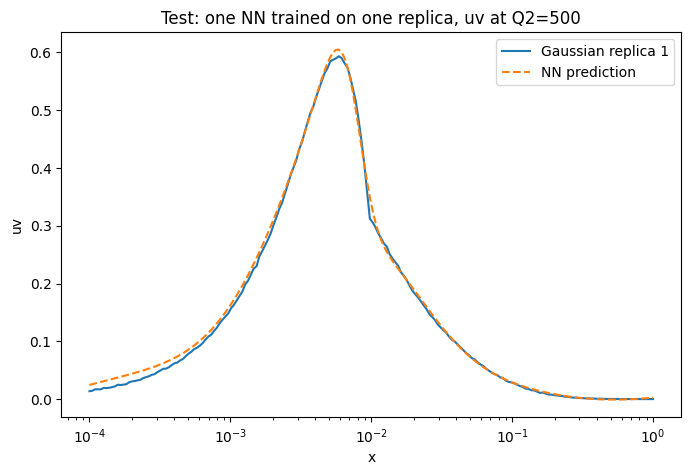

In [12]:
with torch.no_grad():
    test_pred_scaled = test_model(X).cpu().numpy().flatten()
    test_pred = test_pred_scaled * y_scale

plt.figure(figsize=(8, 5))

plt.plot(x_grid, gaussian_replicas[0], label="Gaussian replica 1")
plt.plot(x_grid, test_pred, "--", label="NN prediction")

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(flavor)
plt.title(f"Test: one NN trained on one replica, {flavor} at Q2={Q2_value}")
plt.legend()
plt.show()

In [13]:
models = []
losses = []

max_epochs = 5000
target_loss = 1e-5

for r in range(n_new_replicas):
    print("Training replica", r + 1, "of", n_new_replicas)

    model = SimpleNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    y_train = gaussian_replicas[r] / y_scale
    y_train = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32).to(device)

    for epoch in range(max_epochs):
        optimizer.zero_grad()

        y_pred = model(X)
        loss = torch.mean((y_pred - y_train) ** 2)

        loss.backward()
        optimizer.step()

        # Early stopping
        if loss.item() < target_loss:
            break

    models.append(model)
    losses.append(loss.item())

    print("  final loss:", loss.item(), "epochs:", epoch + 1)

print("Finished training.")
print("Average final loss:", np.mean(losses))
print("Minimum final loss:", np.min(losses))
print("Maximum final loss:", np.max(losses))

Training replica 1 of 100
  final loss: 7.432591519318521e-05 epochs: 5000
Training replica 2 of 100
  final loss: 0.00023192485969047993 epochs: 5000
Training replica 3 of 100
  final loss: 4.8419562517665327e-05 epochs: 5000
Training replica 4 of 100
  final loss: 0.0002948603068944067 epochs: 5000
Training replica 5 of 100
  final loss: 7.836193981347606e-05 epochs: 5000
Training replica 6 of 100
  final loss: 0.00019566163246054202 epochs: 5000
Training replica 7 of 100
  final loss: 6.689552537864074e-05 epochs: 5000
Training replica 8 of 100
  final loss: 0.00014870555605739355 epochs: 5000
Training replica 9 of 100
  final loss: 0.00014187533815857023 epochs: 5000
Training replica 10 of 100
  final loss: 5.357893314794637e-05 epochs: 5000
Training replica 11 of 100
  final loss: 0.0001089211436919868 epochs: 5000
Training replica 12 of 100
  final loss: 5.493700155057013e-05 epochs: 5000
Training replica 13 of 100
  final loss: 4.326650741859339e-05 epochs: 5000
Training replica

In [14]:
predictions = []

with torch.no_grad():
    for model in models:
        pred_scaled = model(X).cpu().numpy().flatten()
        pred = pred_scaled * y_scale
        predictions.append(pred)

predictions = np.array(predictions)

print("Predictions shape:", predictions.shape)

Predictions shape: (100, 200)


In [15]:
nn_mean = predictions.mean(axis=0)
nn_std = predictions.std(axis=0, ddof=1)

print("NN mean shape:", nn_mean.shape)
print("NN std shape:", nn_std.shape)

NN mean shape: (200,)
NN std shape: (200,)


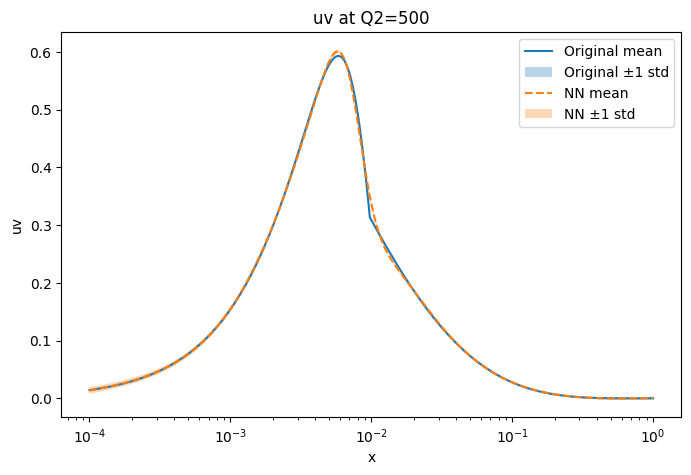

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(x_grid, mean, label="Original mean")
plt.fill_between(
    x_grid,
    mean - std,
    mean + std,
    alpha=0.3,
    label="Original ±1 std"
)

plt.plot(x_grid, nn_mean, "--", label="NN mean")
plt.fill_between(
    x_grid,
    nn_mean - nn_std,
    nn_mean + nn_std,
    alpha=0.3,
    label="NN ±1 std"
)

plt.xscale("log")
plt.xlabel("x")
plt.ylabel(flavor)
plt.title(f"{flavor} at Q2={Q2_value}")
plt.legend()
plt.show()

In [17]:
mean_error = np.mean(np.abs(nn_mean - mean) / (np.abs(mean) + 1e-12))
std_error = np.mean(np.abs(nn_std - std) / (np.abs(std) + 1e-12))

print("Mean relative error:", mean_error)
print("Std relative error:", std_error)

Mean relative error: 140.43572274019022
Std relative error: 1504.4079800991585


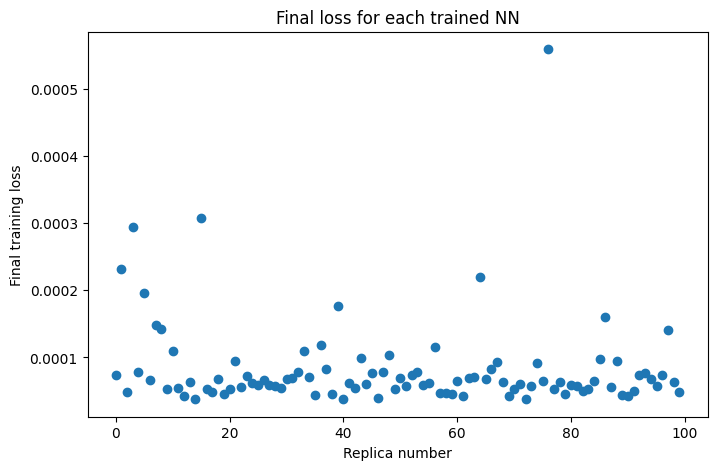

Average loss: 8.327525421918835e-05


In [18]:
plt.figure(figsize=(8, 5))

plt.plot(losses, marker="o", linestyle="none")
plt.xlabel("Replica number")
plt.ylabel("Final training loss")
plt.title("Final loss for each trained NN")
plt.show()

print("Average loss:", np.mean(losses))

In [19]:
output_file = f"bootstrap_nn_predictions_{flavor}_Q2_{Q2_value}.npz"

np.savez(
    output_file,
    x_grid=x_grid,
    mean=mean,
    std=std,
    gaussian_replicas=gaussian_replicas,
    predictions=predictions,
    nn_mean=nn_mean,
    nn_std=nn_std,
    losses=np.array(losses)
)

print("Saved:", output_file)

Saved: bootstrap_nn_predictions_uv_Q2_500.npz
